In [53]:
import itertools
import numpy as np
import pandas as pd
import networkx as nx
from sklearn import datasets
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
import matplotlib.colors as mcolors

#Datos

## IRIS Dataset

In [14]:
iris = datasets.load_iris()

df_iris = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris['target_names'] = df_iris['target'].map({i: name for i, name in enumerate(iris.target_names)})

print(f"Número de filas: {df_iris.shape[0]}, Número de características: {df_iris.shape[1] - 2}")
display(df_iris.head())

Número de filas: 150, Número de características: 4


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


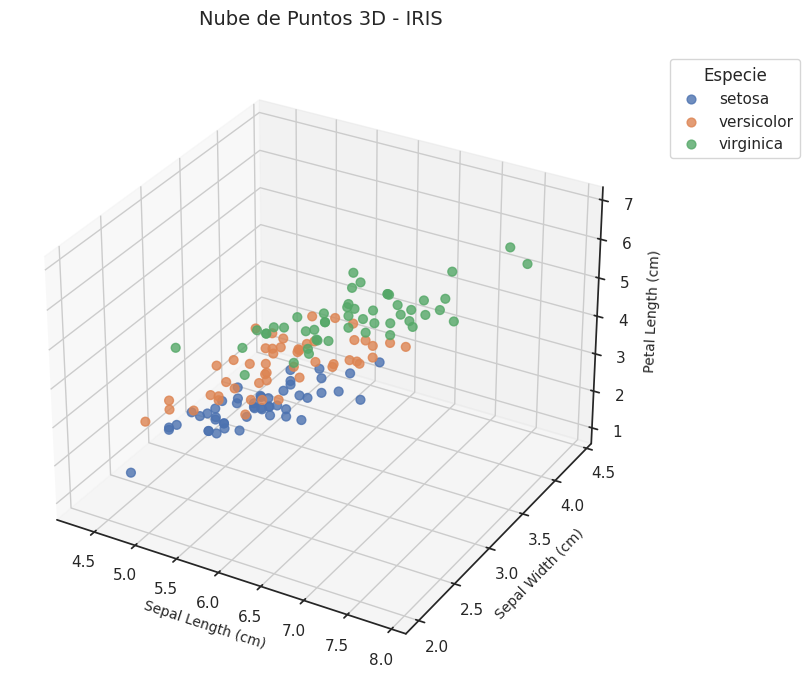

In [42]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

for name, group in df_iris.groupby('target_names'):
    ax.scatter(
        group['sepal length (cm)'],
        group['sepal width (cm)'],
        group['petal length (cm)'],
        label=name,
        s=40,
        alpha=0.8
    )

ax.set_title('Nube de Puntos 3D - IRIS', fontsize=14, pad=20)
ax.set_xlabel('Sepal Length (cm)', fontsize=10)
ax.set_ylabel('Sepal Width (cm)', fontsize=10)
ax.set_zlabel('Petal Length (cm)', fontsize=10)
ax.legend(title='Especie', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Torus

$x = (R + r \cos v) \cos u$

$y = (R + r \cos v) \sin u$

$z = r \sin v$

In [7]:
def generar_toro(n_puntos=1500, R=3.0, r=1.0, ruido=0.1):
    """
    Genera una nube de puntos en forma de toro.
    """
    #Ángulos aleatorios u y v en el intervalo [0, 2pi)
    u = np.random.uniform(0, 2 * np.pi, n_puntos)
    v = np.random.uniform(0, 2 * np.pi, n_puntos)

    #Ecuaciones paramétricas
    x = (R + r * np.cos(v)) * np.cos(u) + np.random.normal(0, ruido, n_puntos)
    y = (R + r * np.cos(v)) * np.sin(u) + np.random.normal(0, ruido, n_puntos)
    z = r * np.sin(v) + np.random.normal(0, ruido, n_puntos)

    return np.column_stack((x, y, z))

#Nube de puntos
nube_toro = generar_toro(n_puntos=2000, R=4.0, r=1.5, ruido=0.15)

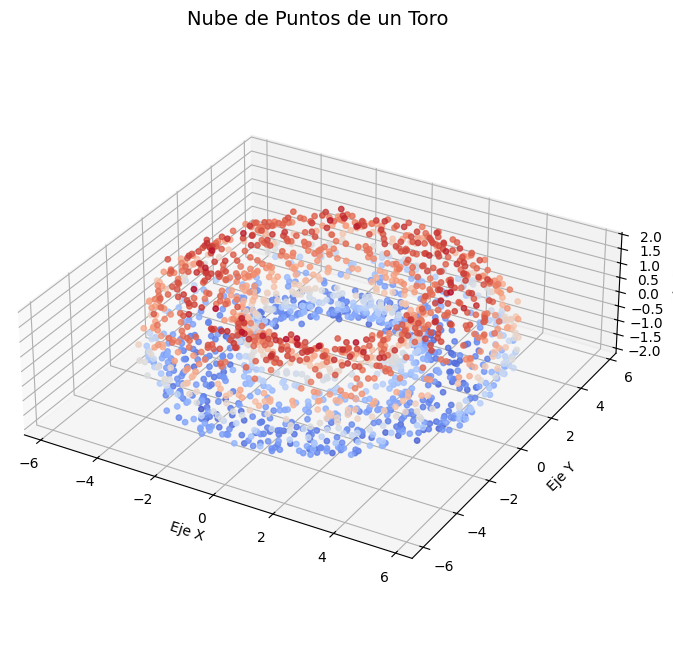

In [11]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Usamos la coordenada Z para darle un mapa de color
disp = ax.scatter(nube_toro[:, 0],
                  nube_toro[:, 1],
                  nube_toro[:, 2],
                  c=nube_toro[:, 2],
                  cmap='coolwarm',
                  s=15,
                  alpha=0.8)

ax.set_title("Nube de Puntos de un Toro", fontsize=14)
ax.set_xlabel("Eje X")
ax.set_ylabel("Eje Y")
ax.set_zlabel("Eje Z")

#Ajustar la escala
ax.set_box_aspect([1, 1, np.ptp(nube_toro[:, 2])/np.ptp(nube_toro[:, 0])])

plt.show()

# Implementación Ball Mapper

## Greedy $\epsilon -$net

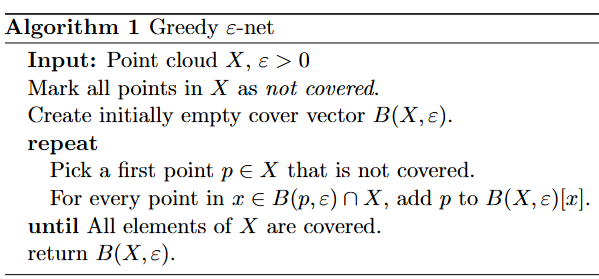

In [15]:
def greedy_epsilon_net(X, eps):
    n_points = X.shape[0]

   #Mark all points in X as not covered.
    covered = np.zeros(n_points, dtype=bool)

   #Create initially empty cover vector B(X, eps).
    #Llave es el índice del punto x, y el Valor es una lista con los centros p que lo cubren.
    B = {i: [] for i in range(n_points)}

    centros = []

    #Estructura de datos para hacer la búsqueda de la intersección B(p, eps)
    tree = KDTree(X)

   #Repeat ... until All elements of X are covered.
    for i in range(n_points):
        if not covered[i]:
           #Pick a first point p in X that is not covered.
            p_idx = i
            centros.append(p_idx)
            #Encontramos los índices de todos los puntos dentro de B(p, eps)
            vecinos_idx = tree.query_ball_point(X[p_idx], eps)

           #For every point in x in B(p, eps) intersección X, add p to B(X, eps)[x]
            for x_idx in vecinos_idx:
                B[x_idx].append(p_idx)
                #Al ser cubierto por p, lo marcamos para no elegirlo como centro después
                covered[x_idx] = True

    return B, centros

In [20]:
#Generamos la nube de puntos del toro
X_toro = generar_toro(n_puntos=2000, R=4.0, r=1.5, ruido=0.15)
eps_toro = 0.8

B_toro, centros_toro = greedy_epsilon_net(X_toro, eps_toro)
print(f"Puntos originales: {X_toro.shape[0]}")
print(f"Centros en la epsilon-net (eps={eps_toro}): {len(centros_toro)}")

Puntos originales: 2000
Centros en la epsilon-net (eps=0.8): 220


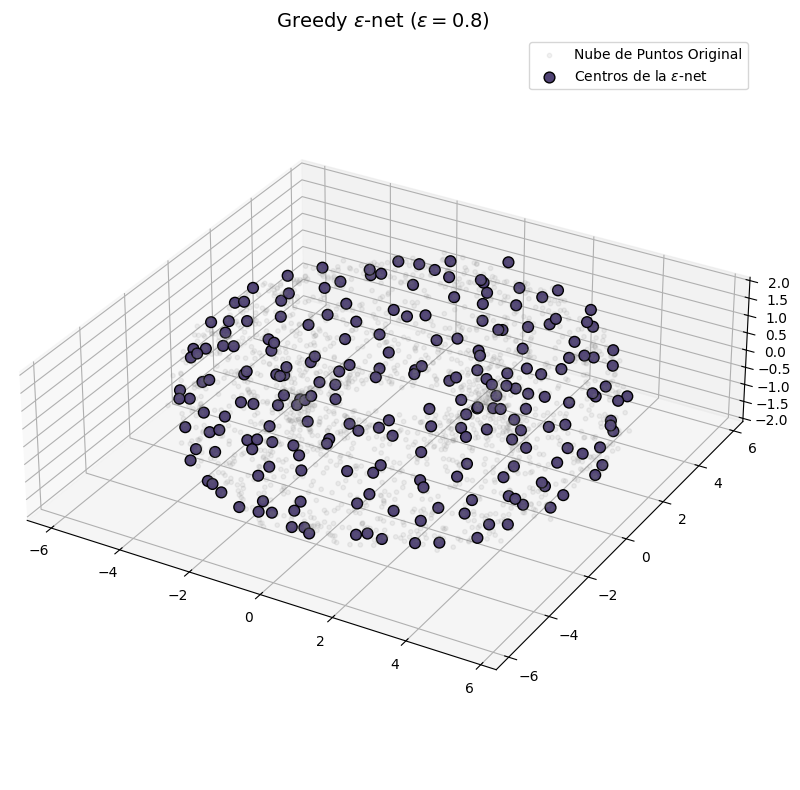

In [23]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Graficar puntos originales
ax.scatter(X_toro[:, 0], X_toro[:, 1], X_toro[:, 2],
           c='gray', alpha=0.1, s=10, label='Nube de Puntos Original')

#Graficar los centros de epsilon-net
coords_centros = X_toro[centros_toro]
ax.scatter(coords_centros[:, 0], coords_centros[:, 1], coords_centros[:, 2],
           c='#504375', alpha=1.0, s=60, edgecolors='black', label=rf'Centros de la $\varepsilon$-net')

ax.set_title(rf"Greedy $\varepsilon$-net ($\varepsilon={eps_toro}$)", fontsize=14)
ax.set_box_aspect([1, 1, np.ptp(X_toro[:, 2])/np.ptp(X_toro[:, 0])])
ax.legend()
plt.tight_layout()
plt.show()

## BallMapper Graph



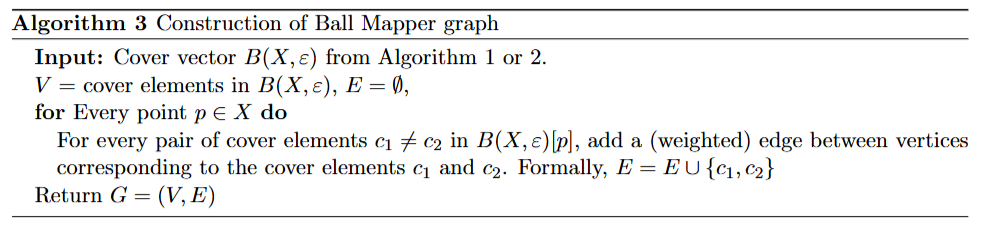

In [27]:
def build_ball_mapper_graph(B, centros):
   #Input
   #E = emptyset
    G = nx.Graph()
   #V = cover elements in B(X, eps)
    #Añadimos los centros como nodos.
    for c in centros:
        G.add_node(c, size=0)

   #For Every point p in X do
    for p, covers in B.items():
        for c in covers:
            G.nodes[c]['size'] += 1

       #For every pair of cover elements c1 != c2 in B(X, eps)[p]
        #Si el punto 'p' está en más de una bola, esas bolas se intersectan.
        if len(covers) > 1:
            for c1, c2 in itertools.combinations(covers, 2):
               #add a (weighted) edge between vertices...
                if G.has_edge(c1, c2):
                    #Si la arista ya existe, aumentamos el peso
                    G[c1][c2]['weight'] += 1
                else:
                    #Si no existe, la creamos con peso 1
                    G.add_edge(c1, c2, weight=1)
    return G

# Multi-Scale Ball Mapper

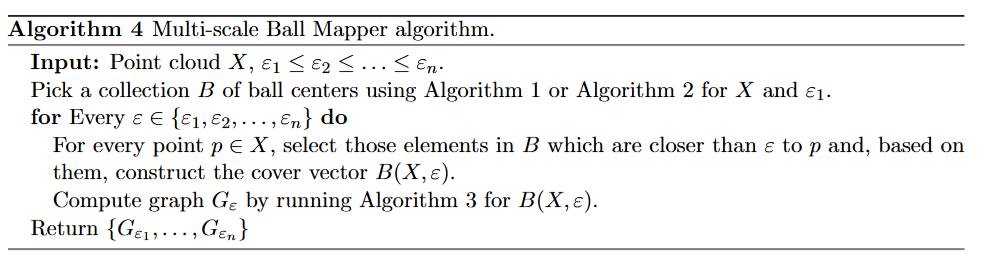

In [44]:
def multi_scale_ball_mapper(X, epsilons):
    """
    epsilons: Lista de radios
    """
    epsilons = sorted(epsilons)
    eps_1 = epsilons[0]

   #"Pick a collection B of ball centers using Algorithm 1 for X and eps_1"
    #Llamamos a Greedy epsilon-net para definir la base
    _, centros = greedy_epsilon_net(X, eps_1)

    filtracion_grafos = []

    tree = KDTree(X)
    n_points = X.shape[0]

   #for Every eps in {eps_1, ..., eps_n} do
    for eps in epsilons:
       #construct the cover vector B(X, eps)
        #Reiniciamos el diccionario de cobertura para este nuevo radio
        B_eps = {i: [] for i in range(n_points)}

        #Para cada centro, buscamos todos los puntos a distancia < eps
        for c_idx in centros:
            vecinos_idx = tree.query_ball_point(X[c_idx], eps)

            #Asignamos este centro a la entrada del vector de cubiertas
            #de cada punto que alcanzó
            for x_idx in vecinos_idx:
                B_eps[x_idx].append(c_idx)

       #Compute graph G_eps by running Algorithm 3 for B(X, eps)
        G_eps = build_ball_mapper_graph(B_eps, centros)

        filtracion_grafos.append(G_eps)

    #"Return {G_eps_1, ..., G_eps_n}"
    return filtracion_grafos, centros

# Resultados

## Puntos Aleatorios

In [51]:
# Generar 10,000 puntos distribuidos uniformemente en el cuadrado [0, 10] x [0, 10]
n_puntos = 10000
X_uniforme = np.random.uniform(0, 10, size=(n_puntos, 2))

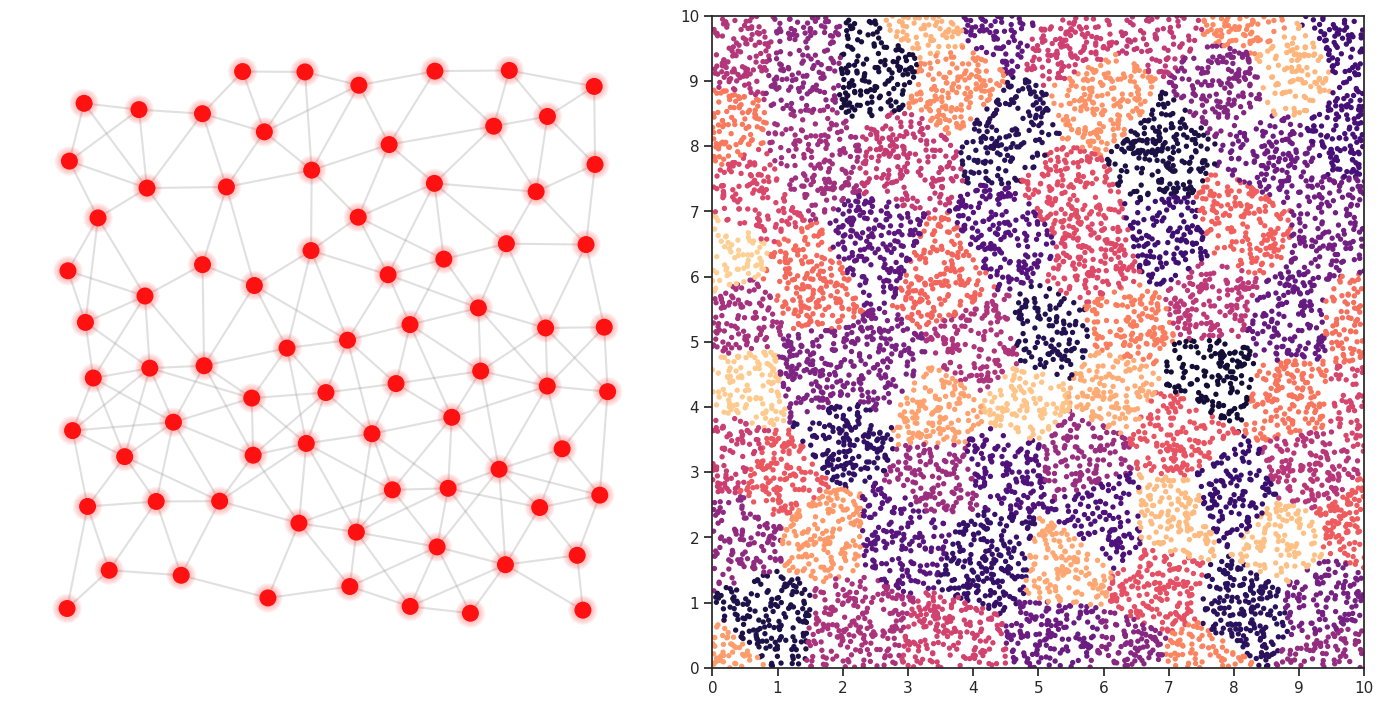

In [56]:
eps_radio = 1.0
B_uniforme, centros_uniforme = greedy_epsilon_net(X_uniforme, eps_radio)
G_uniforme = build_ball_mapper_graph(B_uniforme, centros_uniforme)

#Extraemos las coordenadas (x, y) reales de los centros
coords_centros = X_uniforme[centros_uniforme]
tree_centros = KDTree(coords_centros)

#Para cada uno de los 10,000 puntos, encontramos cuál es el centro más cercano
distancias, indices_cercanos = tree_centros.query(X_uniforme)

#Paleta de colores
cmap_magma = plt.colormaps.get_cmap('magma')
valores_normalizados = np.linspace(0.1, 0.9, len(centros_uniforme))
colores_voronoi = cmap_magma(valores_normalizados)[:, :3]

# Asignamos el color correspondiente a cada uno de los 10,000 puntos
colores_puntos = colores_voronoi[indices_cercanos]





fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

#IZQUIERDA: Grafo Ball Mapper (Dark Mode & Glow) ---
ax1.set_facecolor('#111111')
posiciones_reales = {nodo: X_uniforme[nodo] for nodo in G_uniforme.nodes()}

#Dibujar aristas
nx.draw_networkx_edges(G_uniforme, posiciones_reales, ax=ax1, alpha=0.3, edge_color='#999999', width=1.5)

#Efecto Glow
tamaño_base = 150
for glow_step in range(1, 6):
    nx.draw_networkx_nodes(
        G_uniforme, posiciones_reales, ax=ax1,
        node_size=[tamaño_base * (1 + glow_step * 0.4)] * len(G_uniforme.nodes()),
        node_color='#FF1111', alpha=0.05, linewidths=0
    )

#Rojo sólido
nx.draw_networkx_nodes(
    G_uniforme, posiciones_reales, ax=ax1,
    node_size=tamaño_base, node_color='#FF1111', alpha=1.0, edgecolors='none'
)

ax1.set_xlim(-1, 11)
ax1.set_ylim(-1, 11)
ax1.set_aspect('equal')
ax1.axis('off')






#DERECHA: Nube de Puntos
ax2.set_facecolor('white')

# Graficamos los 10,000 puntos con el color de su centro más cercano
ax2.scatter(X_uniforme[:, 0], X_uniforme[:, 1], c=colores_puntos, s=8, alpha=1.0)

# Configuramos los ejes para que coincidan con la imagen [0, 10]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_xticks(range(11))
ax2.set_yticks(range(11))
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

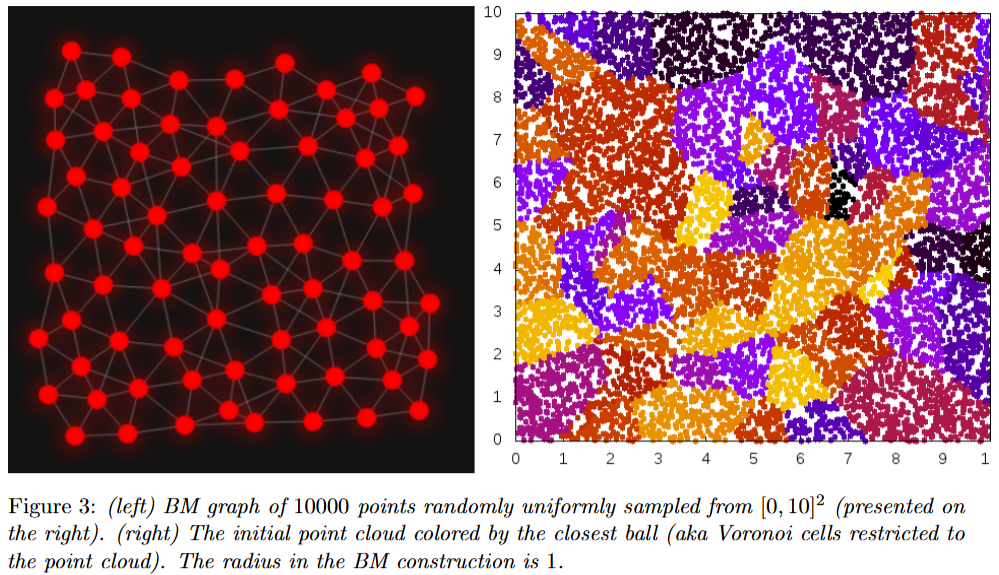

## Torus

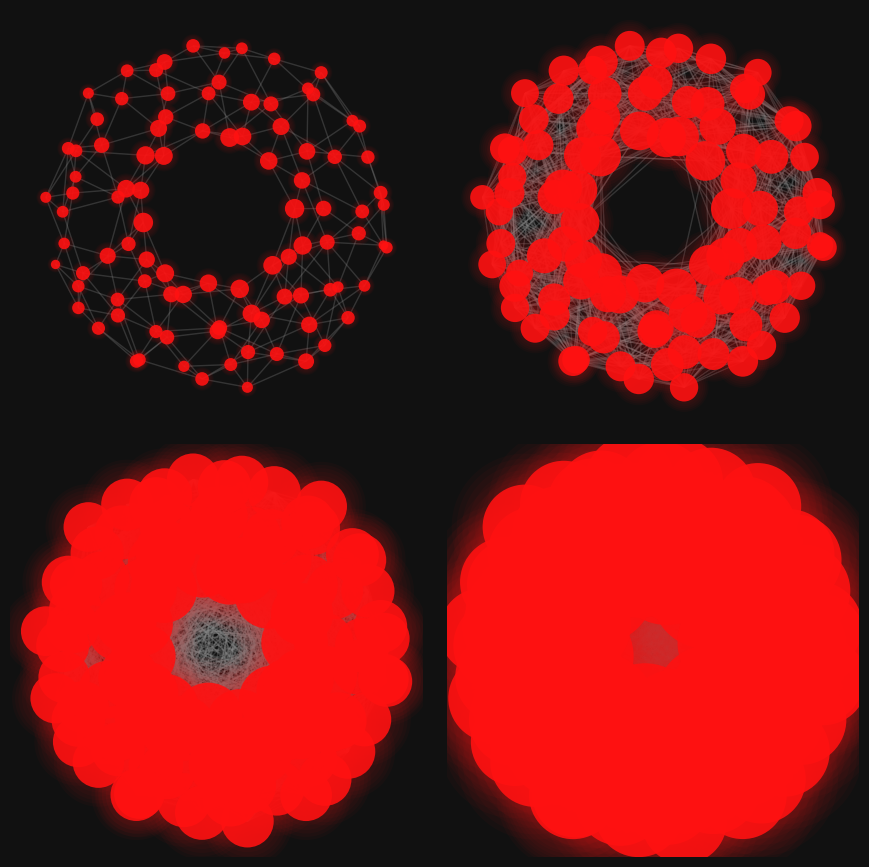

In [60]:
import matplotlib.pyplot as plt
import networkx as nx

#Filtración
escalas_eps_toro = [1.2, 2.5, 4.0, 8.0]

grafos_toro, centros_toro = multi_scale_ball_mapper(nube_toro, escalas_eps_toro)

#Dark Mode
fig, axes = plt.subplots(2, 2, figsize=(11, 11))
fig.patch.set_facecolor('#111111')
axes = axes.flatten()

#Graficar la evolución
for i, eps in enumerate(escalas_eps_toro):
    ax = axes[i]
    ax.set_facecolor('#111111')
    G_actual = grafos_toro[i]

    pos_2d = {nodo: (nube_toro[nodo, 0], nube_toro[nodo, 1]) for nodo in G_actual.nodes()}
    node_sizes = [nx.get_node_attributes(G_actual, 'size')[node] * 3 for node in G_actual.nodes()]

    nx.draw_networkx_edges(G_actual, pos_2d, ax=ax, alpha=0.3, edge_color='#888888')

    #EFECTO GLOW
    for glow_step in range(1, 6):
        nx.draw_networkx_nodes(
            G_actual, pos_2d, ax=ax,
            node_size=[s * (1 + glow_step * 0.4) for s in node_sizes],
            node_color='#FF1111',
            alpha=0.03, linewidths=0
        )
    nx.draw_networkx_nodes(
        G_actual, pos_2d, ax=ax,
        node_size=node_sizes,
        node_color='#FF1111',
        alpha=0.9, edgecolors='none'
    )
    ax.set_aspect('equal')
    ax.axis('off')

plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.show()

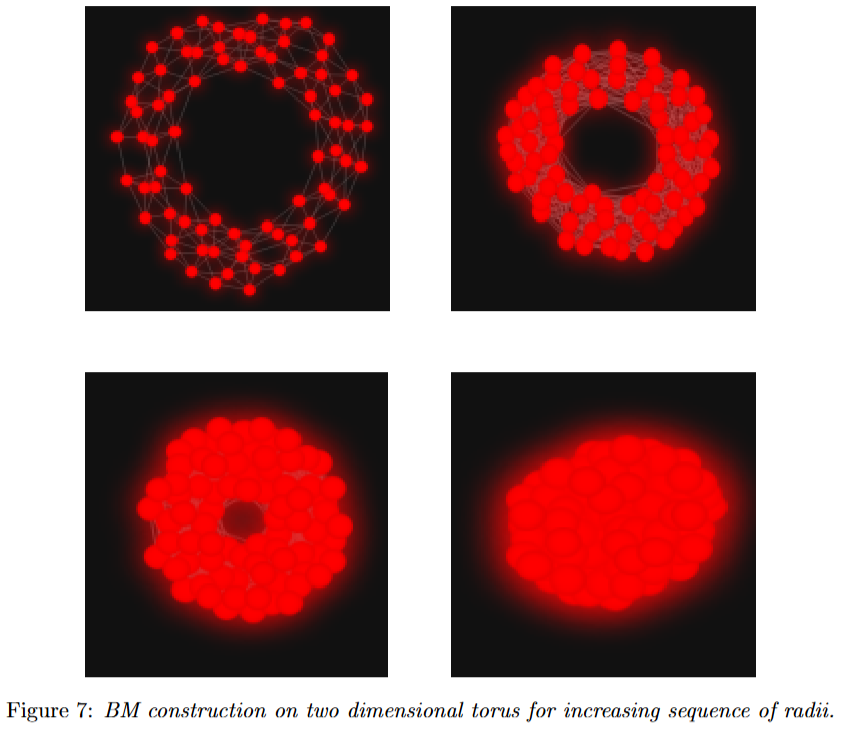

## IRIS Dataset

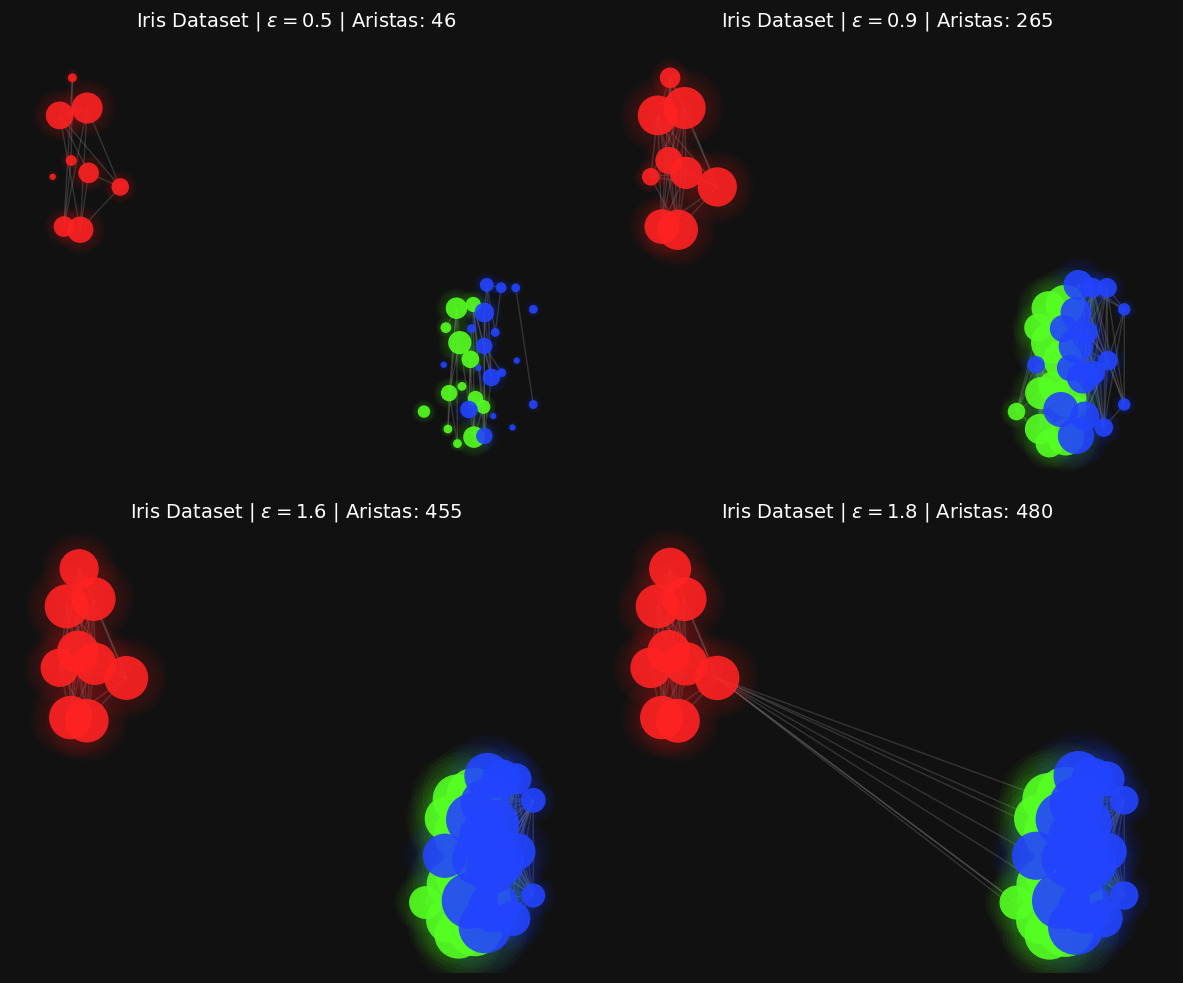

In [49]:
#Filtración
escalas_eps = [0.5, 0.9, 1.6, 1.8]
grafos_multiescala, centros_fijos = multi_scale_ball_mapper(X_iris, escalas_eps)

#y_iris contiene las clases (0: Setosa, 1: Versicolor, 2: Virginica)
y_iris = iris.target

# Paleta de colores neón (Rojo, Verde Lima, Azul)
color_map = {0: '#FF2222', 1: '#55FF22', 2: '#2244FF'}

#Fijar el Layout
pos_fija = nx.spring_layout(grafos_multiescala[-1], k=0.7, iterations=100, seed=42)

#Dark Mode
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor('#111111') # Fondo casi negro
axes = axes.flatten()

for i, eps in enumerate(escalas_eps):
    ax = axes[i]
    ax.set_facecolor('#111111')
    G_actual = grafos_multiescala[i]
    num_aristas = G_actual.number_of_edges()

    #Tamaños basados en la cantidad de puntos en la bola
    node_sizes = [nx.get_node_attributes(G_actual, 'size')[node] * 20 for node in G_actual.nodes()]

    # Asignar color según la etiqueta original del centro de la bola
    node_colors = [color_map[y_iris[node]] for node in G_actual.nodes()]

    # Dibujar las aristas
    nx.draw_networkx_edges(G_actual, pos_fija, ax=ax, alpha=0.3, edge_color='#888888')

    # --- EFECTO GLOW (Simulado por capas) ---
    for glow_step in range(1, 6):
        nx.draw_networkx_nodes(
            G_actual, pos_fija, ax=ax,
            node_size=[s * (1 + glow_step * 0.5) for s in node_sizes],
            node_color=node_colors,
            alpha=0.03, linewidths=0
        )

    # --- NÚCLEO DEL NODO ---
    nx.draw_networkx_nodes(
        G_actual, pos_fija, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.9, edgecolors='none' # Sin borde para mantener el look neón
    )

    # Título del subplot
    ax.set_title(rf"Iris Dataset | $\varepsilon = {eps}$ | Aristas: {num_aristas}",
                 fontsize=14, color='white', pad=10)
    ax.axis('off')

# Ajuste final de márgenes
plt.tight_layout()
plt.show()

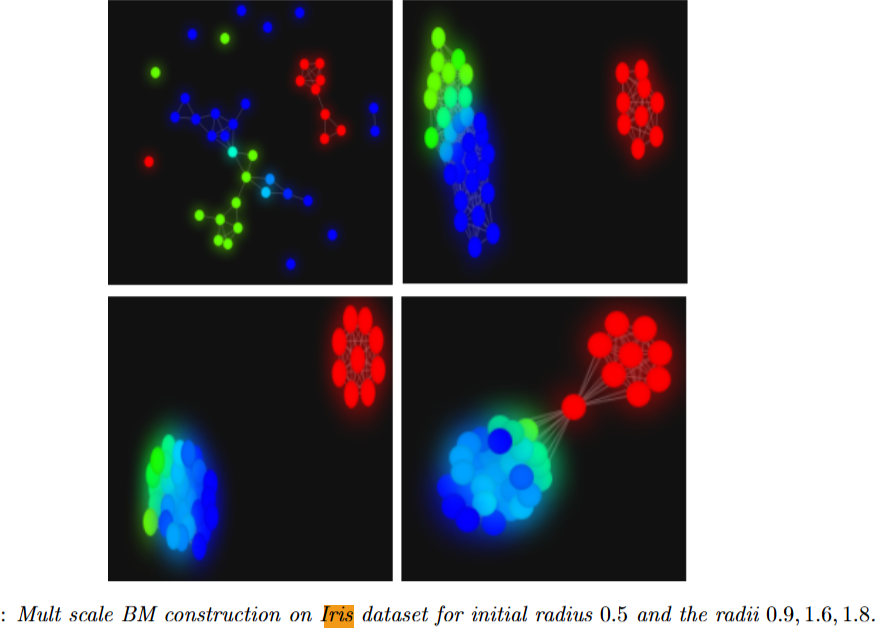